In [1]:
!pip install -q transformers datasets scikit-learn accelerate

In [2]:
import os
NUM_WORKERS = 0 if 'COLAB_GPU' in os.environ else 2

In [3]:
os.environ["HF_TOKEN"] = "******************"

In [4]:
import gc
import json
import os
from tqdm import tqdm
import random
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset as TorchDataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [15]:
MODEL_NAME = "mental/mental-bert-base-uncased"
NUM_LABELS = 9

CONFIG = {

    "summary_csv"  : "/content/summarized_output.csv",
    "train_json"   : "/content/train.json",
    "test_csv"     : "/content/summarized_output_test.csv",
    "output_dir"   : "/content/mentalbert_psydef",

    "max_seq_length": 512,
    "num_epochs"    : 20,
    "batch_size"    : 16,
    "grad_accum"    : 2,
    "learning_rate" : 2e-5,
    "weight_decay"  : 0.01,

    "val_frac"      : 0.10,
    "l7_target"     : 550,
}

In [7]:
os.makedirs(CONFIG["output_dir"], exist_ok=True)

LABEL_NAMES = {
    0: "L0: No Defense",
    1: "L1: Action",
    2: "L2: Major Image-Distort",
    3: "L3: Disavowal",
    4: "L4: Minor Image-Distort",
    5: "L5: Neurotic",
    6: "L6: Obsessional",
    7: "L7: High-Adaptive",
    8: "L8: Needs More Info",
}
EVAL_LABELS = list(range(9))


In [8]:
train_json_df     = pd.read_json(CONFIG["train_json"])
id_to_dialogue_id = dict(zip(train_json_df["id"], train_json_df["dialogue_id"]))

train_raw              = pd.read_csv(CONFIG["summary_csv"])
train_raw["dialogue_id"] = train_raw["id"].map(id_to_dialogue_id)
train_raw["label"]       = train_raw["label"].astype(int)

print(f"  Raw train rows : {len(train_raw)}")
print(f"\nLabel distribution (raw):")
for lbl, cnt in sorted(Counter(train_raw["label"].values).items()):
    bar = "█" * int(cnt / len(train_raw) * 40)
    print(f"  {LABEL_NAMES[lbl]:<35} {cnt:>4} ({cnt/len(train_raw)*100:4.1f}%) {bar}")

  Raw train rows : 1864

Label distribution (raw):
  L0: No Defense                       296 (15.9%) ██████
  L1: Action                           108 ( 5.8%) ██
  L2: Major Image-Distort               61 ( 3.3%) █
  L3: Disavowal                         99 ( 5.3%) ██
  L4: Minor Image-Distort               84 ( 4.5%) █
  L5: Neurotic                          48 ( 2.6%) █
  L6: Obsessional                      172 ( 9.2%) ███
  L7: High-Adaptive                    968 (51.9%) ████████████████████
  L8: Needs More Info                   28 ( 1.5%) 


In [9]:
_, val_idx = train_test_split(
    range(len(train_raw)),
    test_size   = CONFIG["val_frac"],
    random_state= SEED,
    stratify    = train_raw["label"].values,
)
val_df   = train_raw.iloc[val_idx].reset_index(drop=True)
train_df = train_raw.drop(index=val_idx).reset_index(drop=True)

print(f"\n  Train : {len(train_df)}  |  Val : {len(val_df)}")
print(f"  Val label coverage: {sorted(val_df['label'].unique().tolist())}")


  Train : 1677  |  Val : 187
  Val label coverage: [0, 1, 2, 3, 4, 5, 6, 7, 8]


In [10]:
# undersampling of L7
l7_count  = (train_df["label"] == 7).sum()
l7_target = min(CONFIG["l7_target"], l7_count)

train_df_bal = pd.concat([
    train_df[train_df["label"] != 7],
    train_df[train_df["label"] == 7].sample(n=l7_target, random_state=SEED),
], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

l7_pct = Counter(train_df_bal["label"].values)[7] / len(train_df_bal) * 100
print(f"\nAfter L7 undersampling: {len(train_df_bal)} samples  (L7={l7_pct:.1f}%)")


After L7 undersampling: 1356 samples  (L7=40.6%)


In [11]:
def compute_class_weights(df, n_classes=9):
    counts = Counter(df["label"].values)
    N = len(df)
    w = {c: N / (n_classes * max(counts.get(c, 1), 1)) for c in range(n_classes)}
    return torch.tensor([w[c] for c in range(n_classes)], dtype=torch.float32)

class_weight_tensor = compute_class_weights(train_df_bal)
print("\nClass weights:")
for c in range(9):
    print(f"  {LABEL_NAMES[c]:<35} w={class_weight_tensor[c]:.3f}")



Class weights:
  L0: No Defense                      w=0.566
  L1: Action                          w=1.553
  L2: Major Image-Distort             w=2.739
  L3: Disavowal                       w=1.693
  L4: Minor Image-Distort             w=1.982
  L5: Neurotic                        w=3.504
  L6: Obsessional                     w=0.972
  L7: High-Adaptive                   w=0.274
  L8: Needs More Info                 w=6.027


In [12]:
def build_text(summary: str, current_text: str) -> str:

    return str(summary).strip(), str(current_text).strip()

In [13]:
class DefenseDataset(TorchDataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int, has_labels=True):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_len    = max_len
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text_a, text_b = build_text(row["summary"], row["current_text"])

        enc = self.tokenizer(
            text_a,
            text_b,
            max_length      = self.max_len,
            padding         = "max_length",
            truncation      = True,
            return_tensors  = "pt",
        )

        item = {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if "token_type_ids" in enc:
            item["token_type_ids"] = enc["token_type_ids"].squeeze(0)
        if self.has_labels:
            item["labels"] = torch.tensor(int(row["label"]), dtype=torch.long)
        return item


In [14]:
print(f"\nLoading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"  Vocab size: {tokenizer.vocab_size}")

print(f"Loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = NUM_LABELS,
)
model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"  Parameters : {total_params/1e6:.1f}M")

train_dataset = DefenseDataset(train_df_bal, tokenizer, CONFIG["max_seq_length"])
val_dataset   = DefenseDataset(val_df,       tokenizer, CONFIG["max_seq_length"])


Loading tokenizer: mental/mental-bert-base-uncased


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Vocab size: 30522
Loading model: mental/mental-bert-base-uncased


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if 

  Parameters : 109.5M


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size = CONFIG["batch_size"],
    shuffle    = True,
    num_workers= 2,
    pin_memory = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size = CONFIG["batch_size"] * 2,
    shuffle    = False,
    num_workers= 2,
    pin_memory = True,
)
print(f"\nDataLoaders ready.")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val   batches : {len(val_loader)}")


DataLoaders ready.
  Train batches : 85
  Val   batches : 6


In [17]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CONFIG["learning_rate"],
    weight_decay = CONFIG["weight_decay"],
)

total_steps  = (len(train_loader) // CONFIG["grad_accum"]) * CONFIG["num_epochs"]
warmup_steps = max(1, int(total_steps * 0.06))

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = warmup_steps,
    num_training_steps= total_steps,
)

loss_fn = nn.CrossEntropyLoss(
    weight    = class_weight_tensor.to(DEVICE),
    reduction = "mean",
)

print(f"\nOptimizer  : AdamW  lr={CONFIG['learning_rate']}  wd={CONFIG['weight_decay']}")
print(f"Total steps: {total_steps}  Warmup: {warmup_steps}")


Optimizer  : AdamW  lr=2e-05  wd=0.01
Total steps: 840  Warmup: 50


In [18]:
def evaluate(mdl, loader):
    mdl.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch   = {k: v.to(DEVICE) for k, v in batch.items()}
            labels  = batch.pop("labels")
            outputs = mdl(**batch)
            preds   = outputs.logits.argmax(dim=-1)
            all_preds .extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    macro_f1 = f1_score(all_labels, all_preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return macro_f1, acc, all_labels, all_preds

In [19]:
print(f"  Epochs      : {CONFIG['num_epochs']}")
print(f"  Batch size  : {CONFIG['batch_size']}  (grad_accum={CONFIG['grad_accum']})")


best_f1       = 0.0
best_epoch    = 0
history       = []
all_step_losses = []



for epoch in range(1, CONFIG["num_epochs"] + 1):
    model.train()
    optimizer.zero_grad()
    epoch_losses = []
    t0 = time.time()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{CONFIG['num_epochs']}")

    for step, batch in enumerate(progress_bar, 1):
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        labels = batch.pop("labels")

        outputs = model(**batch)
        loss    = loss_fn(outputs.logits, labels)
        loss    = loss / CONFIG["grad_accum"]
        loss.backward()

        epoch_losses.append(loss.item() * CONFIG["grad_accum"])
        all_step_losses.append(loss.item() * CONFIG["grad_accum"])

        if step % CONFIG["grad_accum"] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        # ── update progress bar ──
        avg_loss = sum(epoch_losses[-50:]) / min(len(epoch_losses), 50)
        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "lr"  : f"{scheduler.get_last_lr()[0]:.2e}",
        })

    # ── Epoch validation ──────────────────────────────────────────────────
    macro_f1, acc, true_l, pred_l = evaluate(model, val_loader)
    elapsed = time.time() - t0
    is_best = macro_f1 > best_f1

    history.append({"epoch": epoch, "f1": macro_f1, "acc": acc,
                    "loss": np.mean(epoch_losses)})

    marker = "← NEW BEST" if is_best else f"(best: {best_f1:.4f})"
    print(f"Epoch {epoch:02d}/{CONFIG['num_epochs']}  "
          f"loss={np.mean(epoch_losses):.4f}  "
          f"val_F1={macro_f1:.4f} {marker}  "
          f"acc={acc:.4f}  {elapsed:.0f}s")

    if is_best:
        best_f1    = macro_f1
        best_epoch = epoch
        best_path  = os.path.join(CONFIG["output_dir"], "best_model")
        model.save_pretrained(best_path)
        tokenizer.save_pretrained(best_path)
        print(f"Saved → {best_path}")

  Epochs      : 20
  Batch size  : 16  (grad_accum=2)


Epoch 01/20: 100%|██████████| 85/85 [02:02<00:00,  1.44s/it, loss=2.1810, lr=1.68e-05]


Epoch 01/20  loss=2.1897  val_F1=0.1446 ← NEW BEST  acc=0.2834  128s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved → /content/mentalbert_psydef/best_model


...

Epoch 18/20  loss=0.0387  val_F1=0.2847 (best: 0.3032)  acc=0.6096  135s


Epoch 19/20: 100%|██████████| 85/85 [02:09<00:00,  1.52s/it, loss=0.0374, lr=1.39e-07]


Epoch 19/20  loss=0.0387  val_F1=0.2808 (best: 0.3032)  acc=0.6150  135s


Epoch 20/20: 100%|██████████| 85/85 [02:09<00:00,  1.52s/it, loss=0.0395, lr=0.00e+00]


Epoch 20/20  loss=0.0373  val_F1=0.2785 (best: 0.3032)  acc=0.6096  135s


In [20]:
state = {
    "best_val_f1"  : best_f1,
    "best_epoch"   : best_epoch,
    "model_name"   : MODEL_NAME,
    "history"      : history,
}
with open(os.path.join(CONFIG["output_dir"], "training_state.json"), "w") as f:
    json.dump(state, f, indent=2)

print(f"  Best val Macro F1 : {best_f1:.4f}  (epoch {best_epoch})")
for h in history:
    mark = " ← BEST" if h["epoch"] == best_epoch else ""
    print(f"    Epoch {h['epoch']:02d}: F1={h['f1']:.4f}  acc={h['acc']:.4f}  "
          f"loss={h['loss']:.4f}{mark}")


  Best val Macro F1 : 0.3032  (epoch 7)
    Epoch 01: F1=0.1446  acc=0.2834  loss=2.1897
    Epoch 02: F1=0.1925  acc=0.3690  loss=2.0394
    Epoch 03: F1=0.2599  acc=0.4652  loss=1.8149
    Epoch 04: F1=0.2644  acc=0.4920  loss=1.5547
    Epoch 05: F1=0.2785  acc=0.5027  loss=1.3054
    Epoch 06: F1=0.2823  acc=0.5027  loss=1.0753
    Epoch 07: F1=0.3032  acc=0.5401  loss=0.8331 ← BEST
    Epoch 08: F1=0.2999  acc=0.5508  loss=0.6003
    Epoch 09: F1=0.2521  acc=0.5187  loss=0.4192
    Epoch 10: F1=0.2557  acc=0.6043  loss=0.2951
    Epoch 11: F1=0.2681  acc=0.5722  loss=0.2108
    Epoch 12: F1=0.2657  acc=0.5722  loss=0.1488
    Epoch 13: F1=0.2709  acc=0.5882  loss=0.1127
    Epoch 14: F1=0.2521  acc=0.6096  loss=0.0761
    Epoch 15: F1=0.2757  acc=0.6150  loss=0.0584
    Epoch 16: F1=0.2793  acc=0.6150  loss=0.0491
    Epoch 17: F1=0.2800  acc=0.6096  loss=0.0468
    Epoch 18: F1=0.2847  acc=0.6096  loss=0.0387
    Epoch 19: F1=0.2808  acc=0.6150  loss=0.0387
    Epoch 20: F1=0.278

In [21]:
print(f"\n{'='*60}")
print("VALIDATION REPORT")
print(f"{'='*60}")

best_model = AutoModelForSequenceClassification.from_pretrained(
    best_path, num_labels=NUM_LABELS
).to(DEVICE)
macro_f1, acc, true_l, pred_l = evaluate(best_model, val_loader)

print(f"Accuracy : {acc:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")
print(classification_report(
    true_l, pred_l,
    labels       = EVAL_LABELS,
    target_names = [LABEL_NAMES[i] for i in range(9)],
    digits       = 4,
    zero_division= 0,
))


VALIDATION REPORT


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Accuracy : 0.5401
Macro F1 : 0.3032
                         precision    recall  f1-score   support

         L0: No Defense     0.7105    0.9000    0.7941        30
             L1: Action     0.2727    0.2727    0.2727        11
L2: Major Image-Distort     0.1176    0.3333    0.1739         6
          L3: Disavowal     0.3333    0.1000    0.1538        10
L4: Minor Image-Distort     0.1905    0.5000    0.2759         8
           L5: Neurotic     0.1250    0.2000    0.1538         5
        L6: Obsessional     0.2500    0.1765    0.2069        17
      L7: High-Adaptive     0.8000    0.6186    0.6977        97
    L8: Needs More Info     0.0000    0.0000    0.0000         3

               accuracy                         0.5401       187
              macro avg     0.3111    0.3446    0.3032       187
           weighted avg     0.6008    0.5401    0.5539       187



In [22]:
test_df = pd.read_csv(CONFIG["test_csv"])
test_df["label"] = test_df["label"].astype(int)
print(f"Test samples: {len(test_df)}")

test_dataset = DefenseDataset(
    test_df, tokenizer, CONFIG["max_seq_length"], has_labels=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size = CONFIG["batch_size"] * 2,
    shuffle    = False,
    num_workers= 2,
    pin_memory = True,
)

macro_f1_test, acc_test, true_test, pred_test = evaluate(best_model, test_loader)

print(f"Accuracy : {acc_test:.4f}")
print(f"Macro F1 : {macro_f1_test:.4f}")
print(classification_report(
    true_test, pred_test,
    labels       = EVAL_LABELS,
    target_names = [LABEL_NAMES[i] for i in range(9)],
    digits       = 4,
    zero_division= 0,
))


output_df = test_df.copy()
output_df["prediction"] = pred_test
output_df.to_csv(os.path.join(CONFIG["output_dir"], "predictions.csv"), index=False)
print(f"\nPredictions saved → {CONFIG['output_dir']}/predictions.csv")

Test samples: 472
Accuracy : 0.5297
Macro F1 : 0.3121
                         precision    recall  f1-score   support

         L0: No Defense     0.7467    0.7467    0.7467        75
             L1: Action     0.2286    0.2857    0.2540        28
L2: Major Image-Distort     0.1714    0.3750    0.2353        16
          L3: Disavowal     0.2500    0.0800    0.1212        25
L4: Minor Image-Distort     0.1538    0.2857    0.2000        21
           L5: Neurotic     0.0667    0.0769    0.0714        13
        L6: Obsessional     0.2432    0.2045    0.2222        44
      L7: High-Adaptive     0.7273    0.6584    0.6911       243
    L8: Needs More Info     0.2500    0.2857    0.2667         7

               accuracy                         0.5297       472
              macro avg     0.3153    0.3332    0.3121       472
           weighted avg     0.5607    0.5297    0.5395       472


Predictions saved → /content/mentalbert_psydef/predictions.csv


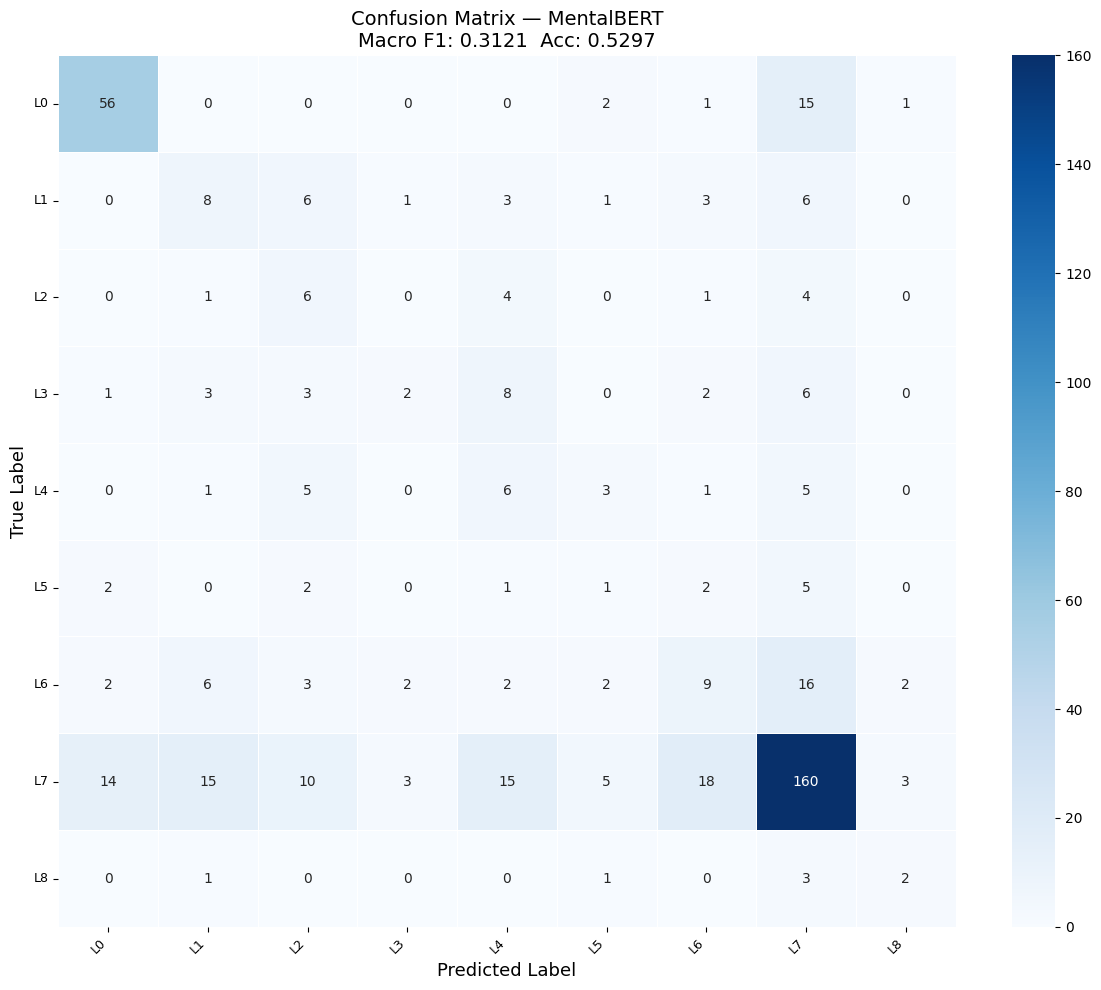

Confusion matrix saved → /content/mentalbert_psydef/confusion_matrix.png


In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

label_names_short = ["L0", "L1", "L2", "L3", "L4", "L5", "L6", "L7", "L8"]

cm = confusion_matrix(true_test, pred_test, labels=EVAL_LABELS)

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names_short,
    yticklabels=label_names_short,
    ax=ax,
    linewidths=0.5,
)

ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title(f"Confusion Matrix — MentalBERT\nMacro F1: {macro_f1_test:.4f}  Acc: {acc_test:.4f}", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

cm_path = os.path.join(CONFIG["output_dir"], "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Confusion matrix saved → {cm_path}")